# Project 3: Cost Structure & CASM Analysis

Deep-dive into United Airlines' per-unit cost structure, benchmarked against major U.S. carriers.

Run `python analysis/pipeline.py --all --csv` first to generate the output CSVs.

In [1]:
import sys
from pathlib import Path

_ANALYSIS = Path.cwd().parent / 'analysis' if Path.cwd().name == 'notebooks' else Path.cwd() / 'analysis'
_OUTPUTS  = Path.cwd().parent / 'outputs'  if Path.cwd().name == 'notebooks' else Path.cwd() / 'outputs'
sys.path.insert(0, str(_ANALYSIS))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

sns.set_theme(style='whitegrid', palette='muted')
UNITED_BLUE  = '#005DAA'
UNITED_GOLD  = '#FFC72C'
ACCENT_RED   = '#D62728'
ACCENT_GREEN = '#2CA02C'
FIG_WIDE     = (14, 5)
FIG_SQ       = (10, 8)

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Imports OK.  Outputs directory:', _OUTPUTS)

Imports OK.  Outputs directory: /Users/sucheen/Documents/airlineRevenueOptimization/Project 3/outputs


In [2]:
def load(filename, **kwargs):
    p = _OUTPUTS / filename
    if p.exists():
        return pd.read_csv(p, **kwargs)
    print(f'  WARNING: {filename} not found — run pipeline.py --all first.')
    return pd.DataFrame()

cost_df   = load('route_cost_summary.csv',        parse_dates=['report_period'])
fuel_df   = load('fuel_cost_detail.csv',           parse_dates=['report_period'])
labor_df  = load('labor_cost_detail.csv',          parse_dates=['report_period'])
maint_df  = load('maintenance_cost_detail.csv',    parse_dates=['report_period'])
bench_df  = load('carrier_casm_benchmarks.csv',    parse_dates=['report_quarter'])
feed_df   = load('casm_cost_feed.csv',             parse_dates=['report_period'])
rates_df  = load('aircraft_maintenance_rates.csv')
crew_df   = load('crew_cost_rates.csv')

print('Cost summary rows:',      len(cost_df))
print('Fuel detail rows:',       len(fuel_df))
print('Labor detail rows:',      len(labor_df))
print('Maintenance detail rows:',len(maint_df))
print('Benchmarks rows:',        len(bench_df))
print('CASM feed rows:',         len(feed_df))

Cost summary rows: 792
Fuel detail rows: 792
Labor detail rows: 792
Maintenance detail rows: 792
Benchmarks rows: 48
CASM feed rows: 792


## 1. CASM Component Breakdown — Fleet-Wide Average

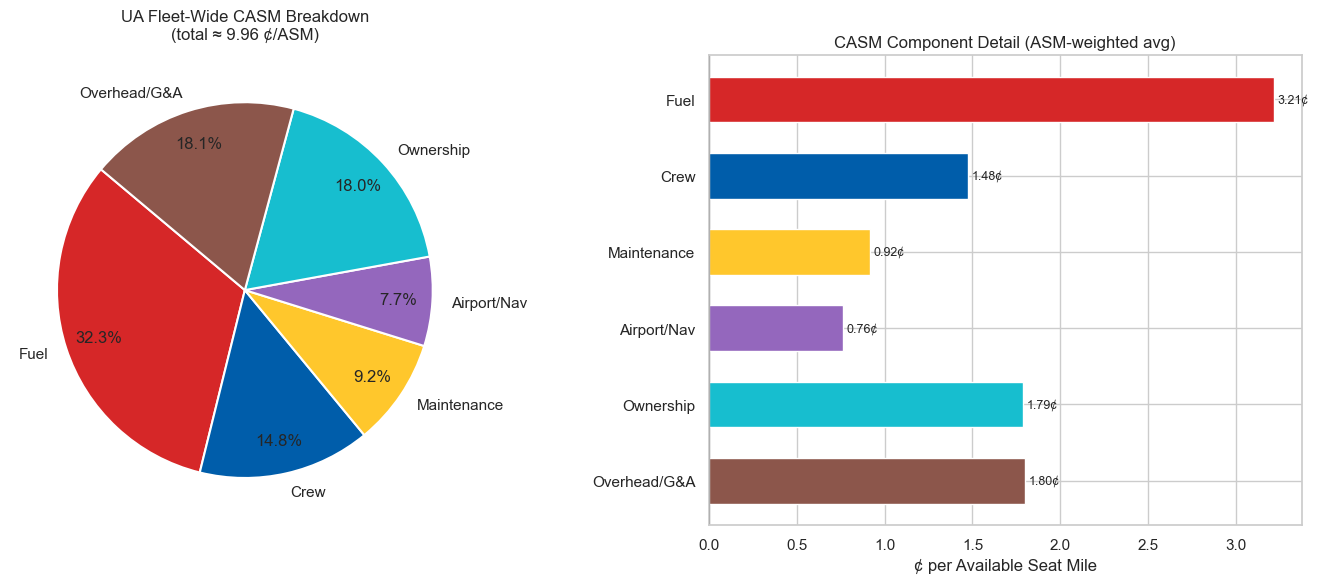


── Fleet-Wide ASM-Weighted CASM Components ──
  Fuel              : 3.212¢/ASM  (32.3%)
  Crew              : 1.476¢/ASM  (14.8%)
  Maintenance       : 0.918¢/ASM  (9.2%)
  Airport/Nav       : 0.764¢/ASM  (7.7%)
  Ownership         : 1.788¢/ASM  (18.0%)
  Overhead/G&A      : 1.800¢/ASM  (18.1%)
  TOTAL             : 9.958¢/ASM


In [3]:
casm_cols = ['casm_fuel', 'casm_crew', 'casm_maintenance', 'casm_airport',
             'casm_ownership', 'casm_overhead']
labels    = ['Fuel', 'Crew', 'Maintenance', 'Airport/Nav', 'Ownership', 'Overhead/G&A']
colors    = [ACCENT_RED, UNITED_BLUE, UNITED_GOLD, '#9467BD', '#17BECF', '#8C564B']

if not cost_df.empty:
    available_cols = [c for c in casm_cols if c in cost_df.columns]
    avail_labels   = [labels[casm_cols.index(c)] for c in available_cols]
    avail_colors   = [colors[casm_cols.index(c)] for c in available_cols]

    # ASM-weighted average (avoids small-route bias)
    asm_w = cost_df['asm'].fillna(1)
    means_cents = [(cost_df[c].fillna(0) * asm_w).sum() / asm_w.sum() * 100
                   for c in available_cols]

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Pie chart
    axes[0].pie(means_cents, labels=avail_labels, colors=avail_colors,
                autopct='%1.1f%%', startangle=140, pctdistance=0.82,
                wedgeprops=dict(edgecolor='white', linewidth=1.5))
    total_casm = sum(means_cents)
    axes[0].set_title(f'UA Fleet-Wide CASM Breakdown\n(total ≈ {total_casm:.2f} ¢/ASM)', pad=12)

    # Bar chart
    bars = axes[1].barh(avail_labels[::-1], means_cents[::-1],
                        color=avail_colors[::-1], edgecolor='white', height=0.6)
    for bar, val in zip(bars, means_cents[::-1]):
        axes[1].text(val + 0.02, bar.get_y() + bar.get_height()/2,
                     f'{val:.2f}¢', va='center', fontsize=9)
    axes[1].set_xlabel('¢ per Available Seat Mile')
    axes[1].set_title('CASM Component Detail (ASM-weighted avg)')
    axes[1].axvline(0, color='black', lw=0.8)

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_casm_breakdown.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n── Fleet-Wide ASM-Weighted CASM Components ──')
    for lbl, val in zip(avail_labels, means_cents):
        print(f'  {lbl:<18}: {val:.3f}¢/ASM  ({val/total_casm*100:.1f}%)')
    print(f'  {"TOTAL":<18}: {total_casm:.3f}¢/ASM')
else:
    print('No cost data loaded.')

## 2. CASM by Aircraft Type

/var/folders/mh/b5m2p8fd04x2knz5_hwd1rqw0000gn/T/ipykernel_81003/3116631376.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series(


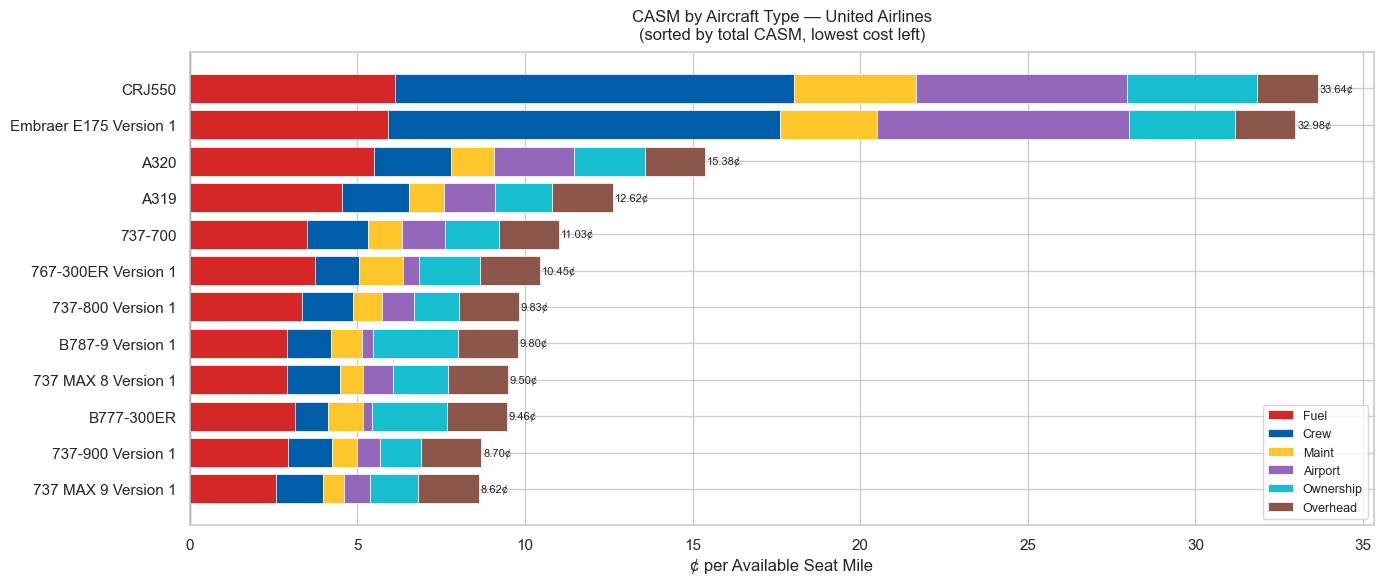


── CASM by Aircraft Type (¢/ASM) ──
      aircraft_variant   Fuel    Crew  Maint  Airport  Ownership  Overhead  casm_total_cents
   737 MAX 9 Version 1 2.5708  1.4186 0.6161   0.7730     1.4419    1.8000            8.6203
     737-900 Version 1 2.9458  1.3046 0.7525   0.6868     1.2116    1.8000            8.7013
            B777-300ER 3.1333  0.9838 1.0582   0.2762     2.2095    1.8000            9.4610
   737 MAX 8 Version 1 2.9052  1.5637 0.6904   0.9122     1.6289    1.8000            9.5003
      B787-9 Version 1 2.8960  1.3281 0.9070   0.3241     2.5429    1.8000            9.7980
     737-800 Version 1 3.3505  1.5326 0.8466   0.9474     1.3485    1.8000            9.8255
   767-300ER Version 1 3.7480  1.2878 1.3162   0.4872     1.8085    1.8000           10.4477
               737-700 3.4950  1.8152 1.0333   1.2581     1.6265    1.8000           11.0282
                  A319 4.5398  1.9903 1.0658   1.5032     1.7204    1.8000           12.6195
                  A320 5.4846  2.

In [4]:
if not cost_df.empty and 'aircraft_variant' in cost_df.columns:
    casm_cols_avail = [c for c in ['casm_fuel','casm_crew','casm_maintenance',
                                    'casm_airport','casm_ownership','casm_overhead']
                       if c in cost_df.columns]
    labels_avail = ['Fuel', 'Crew', 'Maint', 'Airport', 'Ownership', 'Overhead']
    labels_avail = [labels_avail[['casm_fuel','casm_crew','casm_maintenance',
                                   'casm_airport','casm_ownership','casm_overhead'].index(c)]
                    for c in casm_cols_avail]

    by_ac = (
        cost_df.groupby('aircraft_variant')
        .apply(lambda g: pd.Series(
            [(g[c].fillna(0) * g['asm'].fillna(1)).sum() / g['asm'].fillna(1).sum() * 100
             for c in casm_cols_avail],
            index=labels_avail
        ))
        .reset_index()
    )
    by_ac['casm_total_cents'] = by_ac[labels_avail].sum(axis=1)
    by_ac = by_ac.sort_values('casm_total_cents', ascending=True)

    # Stacked horizontal bar
    bar_colors = [ACCENT_RED, UNITED_BLUE, UNITED_GOLD, '#9467BD', '#17BECF', '#8C564B']
    bar_colors = bar_colors[:len(labels_avail)]

    fig, ax = plt.subplots(figsize=(14, max(6, len(by_ac) * 0.45)))
    left = np.zeros(len(by_ac))
    for col, color, lbl in zip(labels_avail, bar_colors, labels_avail):
        vals = by_ac[col].values
        ax.barh(by_ac['aircraft_variant'], vals, left=left, color=color,
                edgecolor='white', linewidth=0.5, label=lbl)
        left += vals

    # Total label
    for y, total in enumerate(by_ac['casm_total_cents']):
        ax.text(total + 0.05, y, f'{total:.2f}¢', va='center', fontsize=8)

    ax.set_xlabel('¢ per Available Seat Mile')
    ax.set_title('CASM by Aircraft Type — United Airlines\n(sorted by total CASM, lowest cost left)', pad=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.axvline(0, color='black', lw=0.8)

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_casm_by_aircraft.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── CASM by Aircraft Type (¢/ASM) ──')
    display_cols = ['aircraft_variant'] + labels_avail + ['casm_total_cents']
    display_cols = [c for c in display_cols if c in by_ac.columns]
    print(by_ac[display_cols].sort_values('casm_total_cents').to_string(index=False))
else:
    print('No cost data loaded.')

## 3. Fuel Cost Analysis — CASM_fuel vs Jet-A Price & Aircraft Type

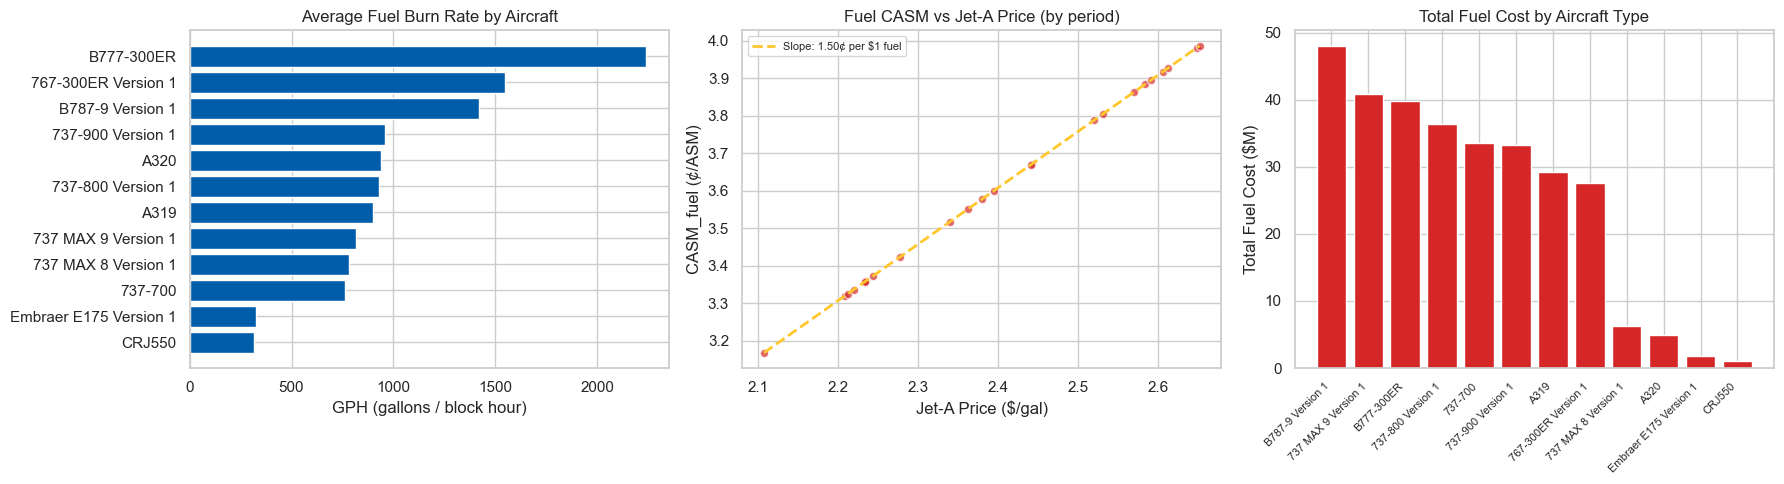

In [5]:
if not fuel_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Fuel GPH distribution
    if 'gph_block_hour' in fuel_df.columns:
        gph_by_ac = fuel_df.groupby('aircraft_variant')['gph_block_hour'].mean().sort_values()
        axes[0].barh(gph_by_ac.index, gph_by_ac.values, color=UNITED_BLUE, edgecolor='white')
        axes[0].set_xlabel('GPH (gallons / block hour)')
        axes[0].set_title('Average Fuel Burn Rate by Aircraft')

    # CASM_fuel vs Jet-A price (scatter by period)
    if 'jet_a_price_usd' in fuel_df.columns and 'casm_fuel' in fuel_df.columns:
        period_avg = fuel_df.groupby('report_period').agg(
            jet_a=('jet_a_price_usd', 'mean'),
            casm_f=('casm_fuel', 'mean')
        ).dropna()
        if not period_avg.empty:
            axes[1].scatter(period_avg['jet_a'], period_avg['casm_f'] * 100,
                            color=ACCENT_RED, alpha=0.7, edgecolors='white')
            axes[1].set_xlabel('Jet-A Price ($/gal)')
            axes[1].set_ylabel('CASM_fuel (¢/ASM)')
            axes[1].set_title('Fuel CASM vs Jet-A Price (by period)')
            # Trend line
            if len(period_avg) >= 2:
                z = np.polyfit(period_avg['jet_a'], period_avg['casm_f'] * 100, 1)
                p = np.poly1d(z)
                x_line = np.linspace(period_avg['jet_a'].min(), period_avg['jet_a'].max(), 50)
                axes[1].plot(x_line, p(x_line), '--', color=UNITED_GOLD, lw=2, label=f'Slope: {z[0]:.2f}¢ per $1 fuel')
                axes[1].legend(fontsize=8)

    # Fuel cost share by aircraft type
    if 'fuel_cost_usd' in fuel_df.columns:
        fuel_share = fuel_df.groupby('aircraft_variant')['fuel_cost_usd'].sum().sort_values(ascending=False).head(12)
        axes[2].bar(range(len(fuel_share)), fuel_share.values / 1e6, color=ACCENT_RED, edgecolor='white')
        axes[2].set_xticks(range(len(fuel_share)))
        axes[2].set_xticklabels(fuel_share.index, rotation=45, ha='right', fontsize=8)
        axes[2].set_ylabel('Total Fuel Cost ($M)')
        axes[2].set_title('Total Fuel Cost by Aircraft Type')

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_fuel_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No fuel data loaded.')

## 4. Labor Cost Analysis — Crew Cost per Block Hour

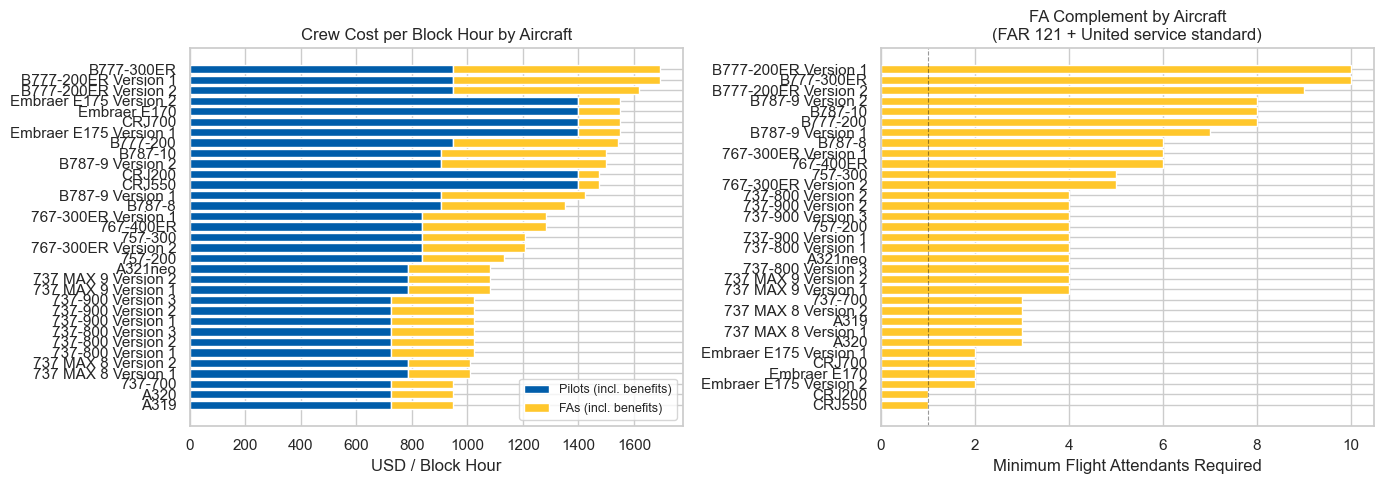


── Crew Cost Rates by Aircraft ──
      aircraft_variant             equipment_group  captain_rate_per_fh  fo_rate_per_fh  pilot_cost_per_bh  n_fas  fa_cost_per_bh  total_crew_cost_per_bh
            B777-300ER      Group_A_widebody_heavy             453.0000        235.0000           949.4400     10        742.5000               1691.9400
  B777-200ER Version 1      Group_A_widebody_heavy             453.0000        235.0000           949.4400     10        742.5000               1691.9400
  B777-200ER Version 2      Group_A_widebody_heavy             453.0000        235.0000           949.4400      9        668.2500               1617.6900
Embraer E175 Version 2                         NaN                  NaN             NaN          1400.0000      2        148.5000               1548.5000
Embraer E175 Version 1                         NaN                  NaN             NaN          1400.0000      2        148.5000               1548.5000
                CRJ700                   

In [6]:
if not crew_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=FIG_WIDE)

    # Crew cost per BH by aircraft
    if 'total_crew_cost_per_bh' in crew_df.columns and 'aircraft_variant' in crew_df.columns:
        crew_plot = crew_df.dropna(subset=['total_crew_cost_per_bh']) \
                           .sort_values('total_crew_cost_per_bh', ascending=True)
        pilot_vals = crew_plot.get('pilot_cost_per_bh', pd.Series(0, index=crew_plot.index)).fillna(0)
        fa_vals    = crew_plot.get('fa_cost_per_bh',    pd.Series(0, index=crew_plot.index)).fillna(0)

        axes[0].barh(crew_plot['aircraft_variant'], pilot_vals,
                     color=UNITED_BLUE, edgecolor='white', label='Pilots (incl. benefits)')
        axes[0].barh(crew_plot['aircraft_variant'], fa_vals, left=pilot_vals,
                     color=UNITED_GOLD, edgecolor='white', label='FAs (incl. benefits)')
        axes[0].set_xlabel('USD / Block Hour')
        axes[0].set_title('Crew Cost per Block Hour by Aircraft')
        axes[0].legend(fontsize=9)

    # FA complement
    if 'n_fas' in crew_df.columns:
        fa_comp = crew_df.dropna(subset=['n_fas']).sort_values('n_fas', ascending=True)
        axes[1].barh(fa_comp['aircraft_variant'], fa_comp['n_fas'],
                     color=UNITED_GOLD, edgecolor='white')
        axes[1].set_xlabel('Minimum Flight Attendants Required')
        axes[1].set_title('FA Complement by Aircraft\n(FAR 121 + United service standard)')
        axes[1].axvline(1, color='black', lw=0.8, linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_labor_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── Crew Cost Rates by Aircraft ──')
    display_cols = [c for c in ['aircraft_variant', 'equipment_group',
                                 'captain_rate_per_fh', 'fo_rate_per_fh',
                                 'pilot_cost_per_bh', 'n_fas', 'fa_cost_per_bh',
                                 'total_crew_cost_per_bh'] if c in crew_df.columns]
    print(crew_df[display_cols].sort_values('total_crew_cost_per_bh',
                                             ascending=False).to_string(index=False))
else:
    print('No crew cost rate data loaded.')

## 5. Maintenance Cost Analysis — DMC Benchmarks

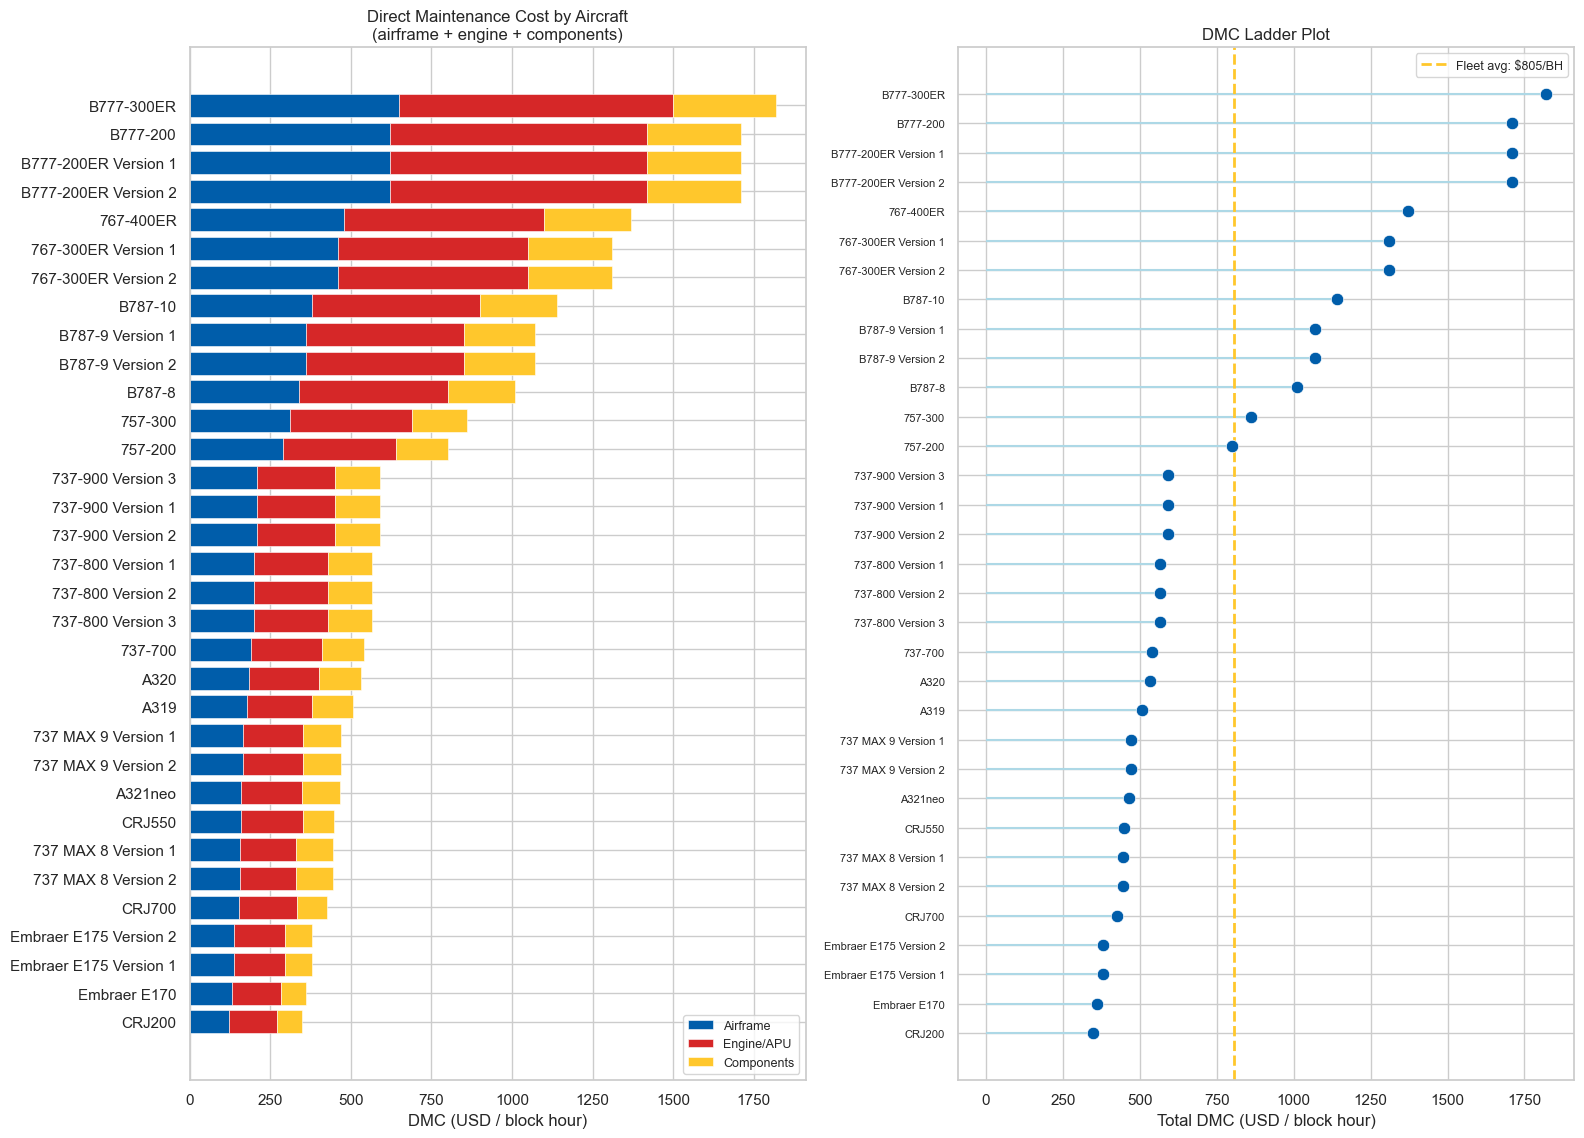

Fleet avg DMC: $805/BH  min: $348  max: $1820


In [7]:
if not rates_df.empty:
    r = rates_df.sort_values('dmc_per_bh_usd', ascending=True).copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(r) * 0.35)))

    # Stacked DMC components
    bar_cols   = [c for c in ['airframe_per_bh_usd','engine_per_bh_usd','components_per_bh_usd'] if c in r.columns]
    bar_labels = ['Airframe', 'Engine/APU', 'Components']
    bar_colors = [UNITED_BLUE, ACCENT_RED, UNITED_GOLD]
    bar_labels = bar_labels[:len(bar_cols)]
    bar_colors = bar_colors[:len(bar_cols)]

    left = np.zeros(len(r))
    for col, lbl, clr in zip(bar_cols, bar_labels, bar_colors):
        axes[0].barh(r['aircraft_variant'], r[col].fillna(0), left=left,
                     color=clr, edgecolor='white', linewidth=0.4, label=lbl)
        left += r[col].fillna(0).values

    axes[0].set_xlabel('DMC (USD / block hour)')
    axes[0].set_title('Direct Maintenance Cost by Aircraft\n(airframe + engine + components)')
    axes[0].legend(fontsize=9)

    # Total DMC scatter
    axes[1].scatter(r['dmc_per_bh_usd'], range(len(r)), s=80,
                    color=UNITED_BLUE, edgecolors='white', linewidth=0.5, zorder=5)
    axes[1].hlines(range(len(r)), 0, r['dmc_per_bh_usd'],
                   color='lightblue', linewidth=1.5, zorder=1)
    axes[1].set_yticks(range(len(r)))
    axes[1].set_yticklabels(r['aircraft_variant'], fontsize=8)
    axes[1].set_xlabel('Total DMC (USD / block hour)')
    axes[1].set_title('DMC Ladder Plot')
    axes[1].axvline(r['dmc_per_bh_usd'].mean(), color=UNITED_GOLD,
                    lw=2, linestyle='--', label=f'Fleet avg: ${r["dmc_per_bh_usd"].mean():.0f}/BH')
    axes[1].legend(fontsize=9)

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_maintenance_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Fleet avg DMC: ${r["dmc_per_bh_usd"].mean():.0f}/BH  '
          f'min: ${r["dmc_per_bh_usd"].min():.0f}  max: ${r["dmc_per_bh_usd"].max():.0f}')
else:
    print('No maintenance rates data loaded.')

## 6. Peer CASM Benchmarking — UA vs AA, DL, WN, AS, B6

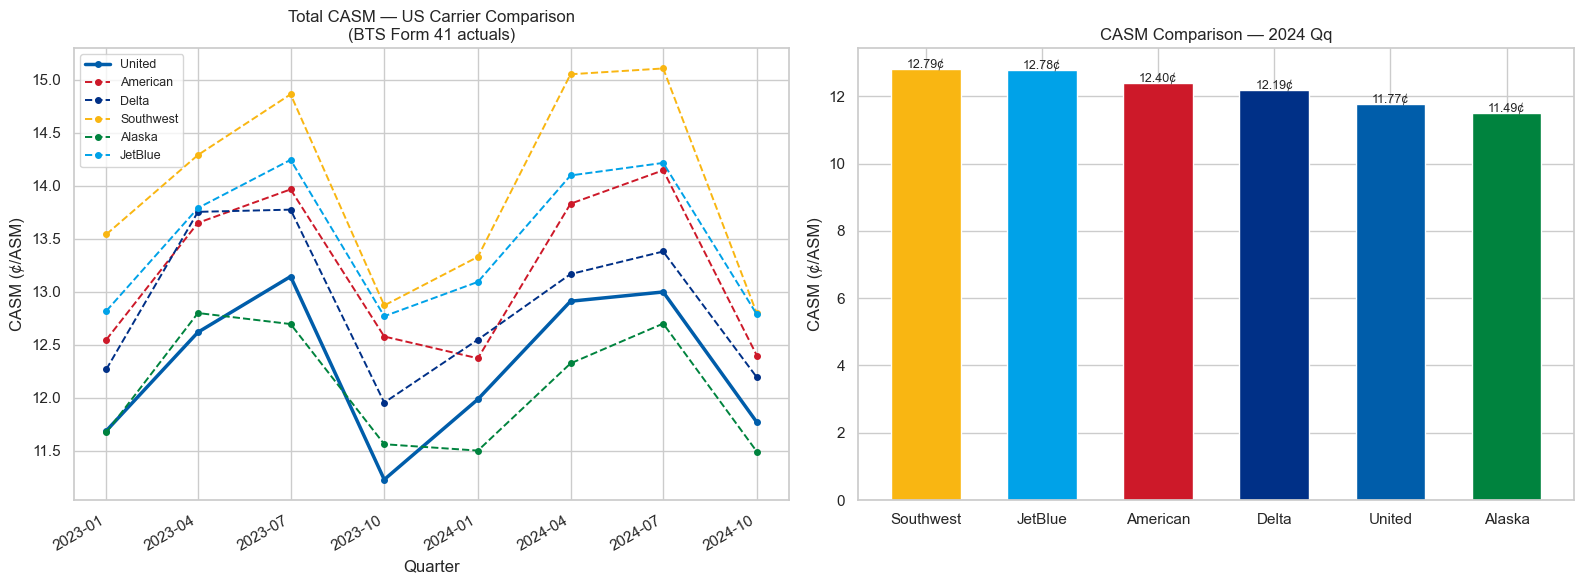


── Latest Quarter CASM (¢/ASM) ──
carrier_code           carrier_name  casm_total_cents  casm_fuel_cents  casm_labor_cents  rasm_cents
          WN Southwest Airlines Co.           12.7945           3.4750            3.8383     16.5620
          B6  JetBlue Airways Corp.           12.7846           3.5963            3.0683     15.8071
          AA American Airlines Inc.           12.3972           3.1266            3.0993     16.7383
          DL   Delta Air Lines Inc.           12.1912           2.9564            3.1697     17.1163
          UA  United Air Lines Inc.           11.7675           3.0819            2.7065     16.3678
          AS   Alaska Airlines Inc.           11.4906           2.8979            2.7577     15.9231


In [8]:
if not bench_df.empty and 'casm_total_cents' in bench_df.columns:
    carrier_order = ['UA', 'AA', 'DL', 'WN', 'AS', 'B6']
    carrier_colors = {
        'UA': UNITED_BLUE, 'AA': '#CD1929', 'DL': '#003087',
        'WN': '#F9B612',   'AS': '#00833E', 'B6': '#00A2E8',
    }
    name_map = {'UA':'United','AA':'American','DL':'Delta',
                'WN':'Southwest','AS':'Alaska','B6':'JetBlue'}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # ── Quarterly CASM trend by carrier ────────────────────────────────────────
    for carrier in carrier_order:
        sub = bench_df[bench_df['carrier_code'] == carrier].sort_values('report_quarter')
        if sub.empty: continue
        lw = 2.5 if carrier == 'UA' else 1.4
        ls = '-'  if carrier == 'UA' else '--'
        axes[0].plot(sub['report_quarter'], sub['casm_total_cents'],
                     label=name_map.get(carrier, carrier),
                     color=carrier_colors.get(carrier, 'grey'),
                     lw=lw, linestyle=ls, marker='o', markersize=4)

    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('CASM (¢/ASM)')
    axes[0].set_title('Total CASM — US Carrier Comparison\n(BTS Form 41 actuals)')
    axes[0].legend(fontsize=9)
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # ── Latest-quarter CASM bar comparison ────────────────────────────────────
    latest_q = bench_df['report_quarter'].max()
    latest   = bench_df[bench_df['report_quarter'] == latest_q].copy()
    latest['carrier_name_short'] = latest['carrier_code'].map(name_map).fillna(latest['carrier_code'])
    latest = latest.sort_values('casm_total_cents', ascending=False)

    bar_colors_list = [carrier_colors.get(c, 'grey') for c in latest['carrier_code']]
    bars = axes[1].bar(latest['carrier_name_short'],
                       latest['casm_total_cents'],
                       color=bar_colors_list, edgecolor='white', width=0.6)

    for bar in bars:
        h = bar.get_height()
        axes[1].text(bar.get_x() + bar.get_width()/2, h + 0.05,
                     f'{h:.2f}¢', ha='center', fontsize=9)

    axes[1].set_ylabel('CASM (¢/ASM)')
    axes[1].set_title(f'CASM Comparison — {latest_q:%Y Q%q}' if hasattr(latest_q, 'strftime') else
                      f'CASM Comparison — Latest Quarter')

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_casm_peer_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── Latest Quarter CASM (¢/ASM) ──')
    show_cols = [c for c in ['carrier_code','carrier_name','casm_total_cents',
                              'casm_fuel_cents','casm_labor_cents','rasm_cents'] if c in latest.columns]
    print(latest[show_cols].to_string(index=False))
elif not bench_df.empty:
    print('Benchmark data loaded but casm_total_cents column missing — check Form 41 data availability.')
else:
    print('No peer benchmark data loaded. Form 41 CSV not present in Project 1/data/.')

## 7. Route-Level CASM Distribution

/var/folders/mh/b5m2p8fd04x2knz5_hwd1rqw0000gn/T/ipykernel_81003/330763813.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  trend = cost_df.groupby(dist_bins)['casm_total'].mean() * 100


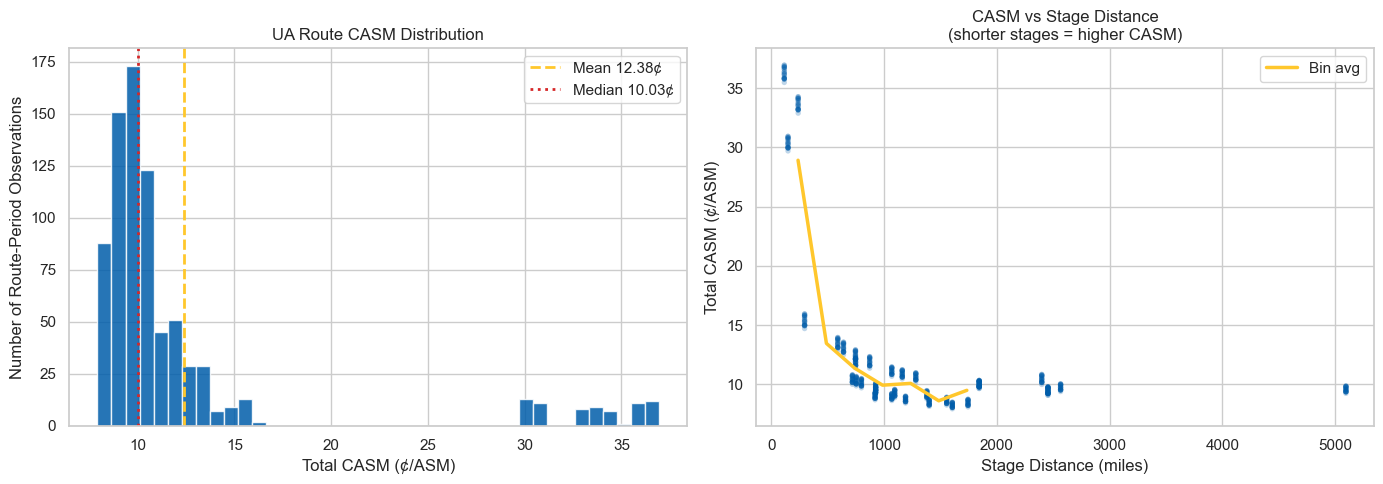

Route CASM stats (¢/ASM): mean=12.38  median=10.03  std=6.88  p10=8.60  p90=15.66


In [9]:
if not cost_df.empty and 'casm_total' in cost_df.columns:
    ct = cost_df['casm_total'].dropna() * 100  # convert to cents

    fig, axes = plt.subplots(1, 2, figsize=FIG_WIDE)

    # Distribution
    axes[0].hist(ct, bins=40, color=UNITED_BLUE, edgecolor='white', alpha=0.85)
    axes[0].axvline(ct.mean(),   color=UNITED_GOLD, lw=2, linestyle='--',
                    label=f'Mean {ct.mean():.2f}¢')
    axes[0].axvline(ct.median(), color=ACCENT_RED,  lw=2, linestyle=':',
                    label=f'Median {ct.median():.2f}¢')
    axes[0].set_xlabel('Total CASM (¢/ASM)')
    axes[0].set_ylabel('Number of Route-Period Observations')
    axes[0].set_title('UA Route CASM Distribution')
    axes[0].legend()

    # CASM vs distance
    if 'distance_mi' in cost_df.columns:
        axes[1].scatter(
            cost_df['distance_mi'],
            cost_df['casm_total'] * 100,
            c=UNITED_BLUE, alpha=0.25, s=15, edgecolors='none'
        )
        axes[1].set_xlabel('Stage Distance (miles)')
        axes[1].set_ylabel('Total CASM (¢/ASM)')
        axes[1].set_title('CASM vs Stage Distance\n(shorter stages = higher CASM)')
        # Moving average
        dist_bins = pd.cut(cost_df['distance_mi'], bins=20)
        trend = cost_df.groupby(dist_bins)['casm_total'].mean() * 100
        trend_x = [interval.mid for interval in trend.index]
        axes[1].plot(trend_x, trend.values, color=UNITED_GOLD, lw=2.5, label='Bin avg')
        axes[1].legend()

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_casm_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'Route CASM stats (¢/ASM): mean={ct.mean():.2f}  median={ct.median():.2f}  '
          f'std={ct.std():.2f}  p10={ct.quantile(0.1):.2f}  p90={ct.quantile(0.9):.2f}')
else:
    print('No cost data loaded.')

## 8. Most & Least Cost-Efficient Routes

/var/folders/mh/b5m2p8fd04x2knz5_hwd1rqw0000gn/T/ipykernel_81003/1736469393.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


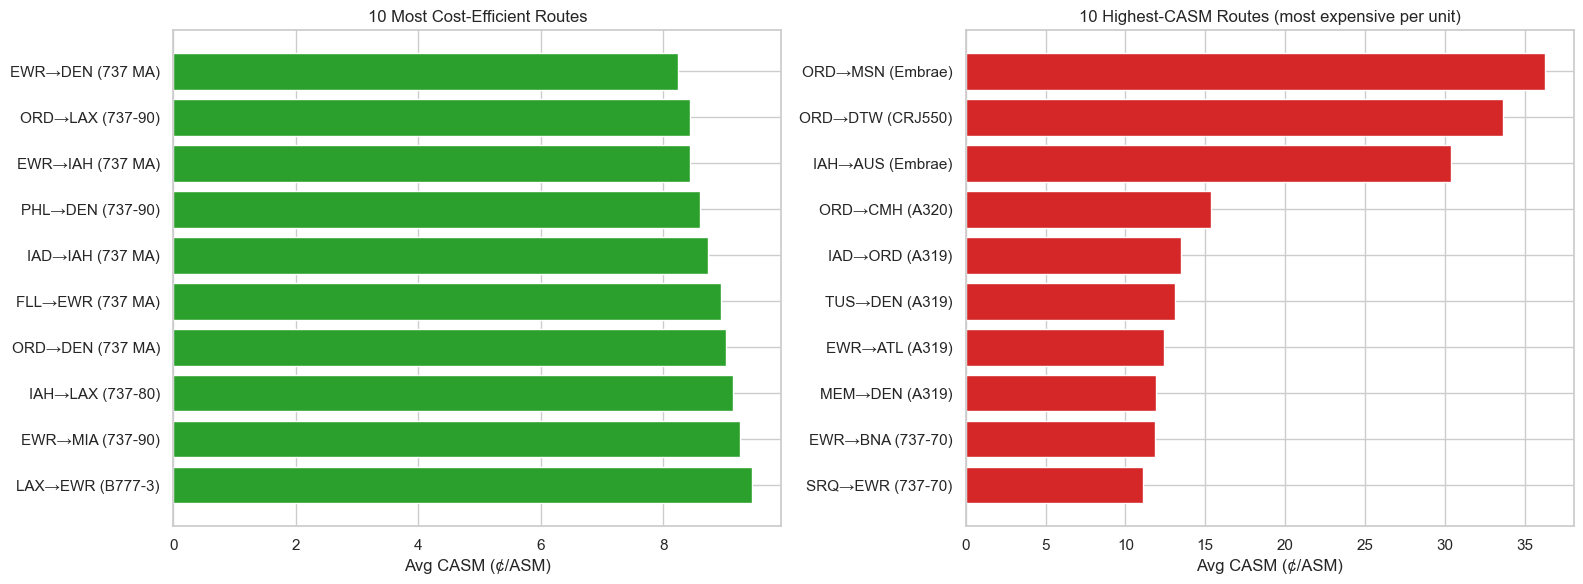


── Top 10 Most Cost-Efficient Routes ──
  route    aircraft_variant  avg_casm_total_cents  avg_distance_mi  n_months
EWR→DEN 737 MAX 9 Version 1                8.2353        1605.0000   24.0000
ORD→LAX   737-900 Version 1                8.4423        1744.0000   24.0000
EWR→IAH 737 MAX 9 Version 1                8.4439        1400.0000   24.0000
PHL→DEN   737-900 Version 1                8.6064        1555.0000   24.0000
IAD→IAH 737 MAX 9 Version 1                8.7341        1190.0000   24.0000
FLL→EWR 737 MAX 9 Version 1                8.9500        1068.0000   24.0000
ORD→DEN 737 MAX 9 Version 1                9.0233         920.0000   24.0000
IAH→LAX   737-800 Version 1                9.1421        1379.0000   24.0000
EWR→MIA   737-900 Version 1                9.2483        1094.0000   24.0000
LAX→EWR          B777-300ER                9.4556        2453.0000   24.0000

── Top 10 Highest-CASM Routes ──
  route       aircraft_variant  avg_casm_total_cents  avg_distance_mi  n_month

In [10]:
if not cost_df.empty and 'casm_total' in cost_df.columns:
    route_agg = (
        cost_df.groupby(['origin_iata','destination_iata','aircraft_variant'])
        .apply(lambda g: pd.Series({
            'avg_casm_total_cents':  (g['casm_total'].fillna(0) * g['asm'].fillna(1)).sum()
                                     / g['asm'].fillna(1).sum() * 100,
            'avg_casm_fuel_cents':   (g.get('casm_fuel', pd.Series(0, index=g.index)).fillna(0)
                                     * g['asm'].fillna(1)).sum() / g['asm'].fillna(1).sum() * 100,
            'avg_distance_mi':       g['distance_mi'].mean() if 'distance_mi' in g else 0,
            'total_cost_usd':        g['total_cost_usd'].sum() if 'total_cost_usd' in g else 0,
            'n_months':              g['report_period'].nunique(),
        }))
        .reset_index()
    )
    route_agg['route'] = route_agg['origin_iata'] + '→' + route_agg['destination_iata']

    top10_efficient   = route_agg.nsmallest(10, 'avg_casm_total_cents')
    top10_inefficient = route_agg.nlargest(10, 'avg_casm_total_cents')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    axes[0].barh(
        top10_efficient['route'] + ' (' + top10_efficient['aircraft_variant'].str[:6] + ')',
        top10_efficient['avg_casm_total_cents'],
        color=ACCENT_GREEN, edgecolor='white'
    )
    axes[0].set_xlabel('Avg CASM (¢/ASM)')
    axes[0].set_title('10 Most Cost-Efficient Routes')

    axes[1].barh(
        top10_inefficient['route'] + ' (' + top10_inefficient['aircraft_variant'].str[:6] + ')',
        top10_inefficient['avg_casm_total_cents'],
        color=ACCENT_RED, edgecolor='white'
    )
    axes[1].set_xlabel('Avg CASM (¢/ASM)')
    axes[1].set_title('10 Highest-CASM Routes (most expensive per unit)')

    for ax in axes:
        ax.invert_yaxis()

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_route_casm_ranking.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('\n── Top 10 Most Cost-Efficient Routes ──')
    print(top10_efficient[['route','aircraft_variant','avg_casm_total_cents','avg_distance_mi','n_months']]
          .to_string(index=False))
    print('\n── Top 10 Highest-CASM Routes ──')
    print(top10_inefficient[['route','aircraft_variant','avg_casm_total_cents','avg_distance_mi','n_months']]
          .to_string(index=False))
else:
    print('No cost data loaded.')

## 9. CASM Cost Feed Preview — Project 4 Input

/var/folders/mh/b5m2p8fd04x2knz5_hwd1rqw0000gn/T/ipykernel_81003/3086716040.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: (g['ua_vs_peer_casm_delta_pct'].fillna(0) * g['asm'].fillna(1)).sum()
/var/folders/mh/b5m2p8fd04x2knz5_hwd1rqw0000gn/T/ipykernel_81003/3086716040.py:54: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  q_ua   = qtr.groupby('quarter').apply(


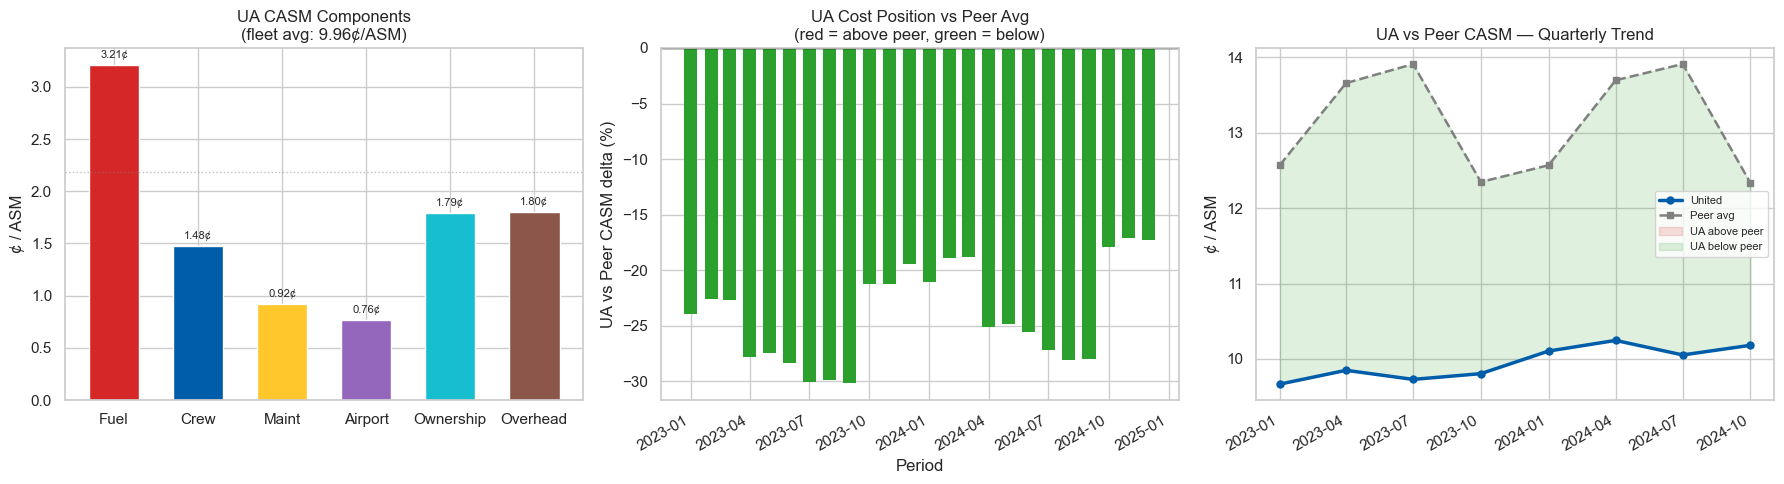

CASM feed: 792 rows | 12 variants | 33 routes
Date range: 2023-01-01 → 2024-12-01
Mean casm_total: 12.379¢/ASM
UA vs peer CASM: -5.4% on avg (below peer)

Feed columns (Project 4 inputs):
['report_period', 'carrier_code', 'origin_iata', 'destination_iata', 'aircraft_variant', 'casm_fuel', 'casm_crew', 'casm_maintenance', 'casm_airport', 'casm_ownership', 'casm_overhead', 'casm_direct', 'casm_total', 'total_cost_usd', 'total_direct_cost_usd', 'fuel_cost_usd', 'crew_cost_usd', 'block_hours', 'asm', 'industry_casm_total_cents', 'ua_vs_peer_casm_delta_pct', 'cost_basis']

Sample row:
report_period                2023-01-01 00:00:00
carrier_code                                  UA
origin_iata                                  SRQ
destination_iata                             EWR
aircraft_variant                         737-700
casm_fuel                                 0.0306
casm_crew                                 0.0181
casm_maintenance                          0.0103
casm_airport         

In [11]:
if not feed_df.empty:
    casm_cols = ['casm_fuel', 'casm_crew', 'casm_maintenance',
                 'casm_airport', 'casm_ownership', 'casm_overhead']
    labels    = ['Fuel', 'Crew', 'Maint', 'Airport', 'Ownership', 'Overhead']
    colors    = [ACCENT_RED, UNITED_BLUE, UNITED_GOLD, '#9467BD', '#17BECF', '#8C564B']

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Left: UA CASM component bar vs peer average ────────────────────────────
    avail_cols   = [c for c in casm_cols if c in feed_df.columns]
    avail_labels = [labels[casm_cols.index(c)] for c in avail_cols]
    avail_colors = [colors[casm_cols.index(c)] for c in avail_cols]

    asm_w      = feed_df['asm'].fillna(1)
    ua_cents   = [(feed_df[c].fillna(0) * asm_w).sum() / asm_w.sum() * 100 for c in avail_cols]
    ua_total   = sum(ua_cents)

    peer_total = (feed_df['industry_casm_total_cents'].dropna().mean()
                  if 'industry_casm_total_cents' in feed_df.columns else None)

    x = range(len(avail_labels))
    bars = axes[0].bar(avail_labels, ua_cents, color=avail_colors, edgecolor='white', width=0.6)
    for bar, val in zip(bars, ua_cents):
        axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.05,
                     f'{val:.2f}¢', ha='center', va='bottom', fontsize=8)
    if peer_total is not None:
        axes[0].axhline(peer_total / len(avail_cols), color='grey', lw=1,
                        linestyle=':', alpha=0.5)
    axes[0].set_ylabel('¢ / ASM')
    axes[0].set_title(f'UA CASM Components\n(fleet avg: {ua_total:.2f}¢/ASM)')

    # ── Middle: UA vs peer CASM delta over time ────────────────────────────────
    if 'ua_vs_peer_casm_delta_pct' in feed_df.columns:
        monthly = (
            feed_df.groupby('report_period')
            .apply(lambda g: (g['ua_vs_peer_casm_delta_pct'].fillna(0) * g['asm'].fillna(1)).sum()
                             / g['asm'].fillna(1).sum())
            .reset_index(name='delta_pct')
        )
        bar_colors_delta = [ACCENT_RED if v > 0 else ACCENT_GREEN
                            for v in monthly['delta_pct']]
        axes[1].bar(monthly['report_period'], monthly['delta_pct'] * 100,
                    color=bar_colors_delta, edgecolor='none', width=20)
        axes[1].axhline(0, color='black', lw=1)
        axes[1].set_xlabel('Period')
        axes[1].set_ylabel('UA vs Peer CASM delta (%)')
        axes[1].set_title('UA Cost Position vs Peer Avg\n(red = above peer, green = below)')
        plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # ── Right: UA total CASM vs peer avg by quarter ───────────────────────────
    if 'industry_casm_total_cents' in feed_df.columns:
        qtr = feed_df.copy()
        qtr['quarter'] = pd.to_datetime(qtr['report_period']).dt.to_period('Q').dt.to_timestamp()
        q_ua   = qtr.groupby('quarter').apply(
            lambda g: (g['casm_total'].fillna(0) * g['asm'].fillna(1)).sum()
                      / g['asm'].fillna(1).sum() * 100
        ).rename('ua_casm_cents')
        q_peer = qtr.groupby('quarter')['industry_casm_total_cents'].mean().rename('peer_casm_cents')
        q_comp = pd.concat([q_ua, q_peer], axis=1).dropna()

        axes[2].plot(q_comp.index, q_comp['ua_casm_cents'],
                     color=UNITED_BLUE, lw=2.5, marker='o', markersize=5, label='United')
        axes[2].plot(q_comp.index, q_comp['peer_casm_cents'],
                     color='grey', lw=1.8, linestyle='--', marker='s', markersize=4, label='Peer avg')
        axes[2].fill_between(q_comp.index, q_comp['ua_casm_cents'], q_comp['peer_casm_cents'],
                             where=q_comp['ua_casm_cents'] > q_comp['peer_casm_cents'],
                             alpha=0.15, color=ACCENT_RED, label='UA above peer')
        axes[2].fill_between(q_comp.index, q_comp['ua_casm_cents'], q_comp['peer_casm_cents'],
                             where=q_comp['ua_casm_cents'] <= q_comp['peer_casm_cents'],
                             alpha=0.15, color=ACCENT_GREEN, label='UA below peer')
        axes[2].set_ylabel('¢ / ASM')
        axes[2].set_title('UA vs Peer CASM — Quarterly Trend')
        axes[2].legend(fontsize=8)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.savefig(_OUTPUTS / 'plot_casm_feed_preview.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── Summary stats ──────────────────────────────────────────────────────────
    print(f'CASM feed: {len(feed_df)} rows | {feed_df["aircraft_variant"].nunique()} variants | '
          f'{feed_df.groupby(["origin_iata","destination_iata"]).ngroups} routes')
    print(f'Date range: {feed_df.report_period.min().date()} → {feed_df.report_period.max().date()}')
    print(f'Mean casm_total: {feed_df["casm_total"].mean()*100:.3f}¢/ASM')
    if 'ua_vs_peer_casm_delta_pct' in feed_df.columns:
        delta = feed_df['ua_vs_peer_casm_delta_pct'].dropna()
        direction = "above" if delta.mean() > 0 else "below"
        print(f'UA vs peer CASM: {delta.mean()*100:+.1f}% on avg ({direction} peer)')
    print('\nFeed columns (Project 4 inputs):')
    print([c for c in feed_df.columns])
    print('\nSample row:')
    print(feed_df.iloc[0].to_string())
else:
    print('No CASM cost feed loaded — run: python analysis/pipeline.py --all --csv')